In [1]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
from snntorch import surrogate
from snntorch import functional as SF

import torch
import torch.nn as nn
import torch.nn.functional as nf
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [2]:
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float

In [3]:
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

In [4]:
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

In [5]:
data, targets = next(iter(train_loader))

In [6]:
data1, targets1 = next(iter(test_loader))

torch.Size([128, 1, 28, 28])
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.

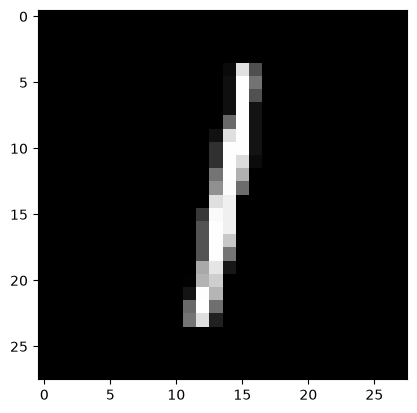

In [7]:
print(data.shape)
print(data[0])
print(data[0]*255)
plt.imshow(data[0].squeeze(),cmap='gray')
plt.show()

In [8]:
# Network Architecture
num_inputs = 28*28
num_hidden = 1000
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.95
spike_grad = surrogate.fast_sigmoid(slope=25)

In [9]:
from snntorch import spikegen

spike_data = spikegen.rate(data, num_steps=num_steps)

print(spike_data.shape)
print(spike_data[:,0,0,:,:])

torch.Size([25, 128, 1, 28, 28])
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0.

In [10]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):

        # x shape:
        # [num_steps, batch_size, 1, 28, 28]

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(num_steps):

            # Take one timestep
            x_t = x[step]

            # Flatten image
            x_t = x_t.view(x_t.size(0), -1)

            cur1 = self.fc1(x_t)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk_rec.append(spk2)
            mem_rec.append(mem2)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

net = Net()

In [11]:
spike_data = spikegen.rate(data, num_steps=num_steps)

spk_rec1, mem_rec = net(spike_data)

print(spk_rec1.shape)

torch.Size([25, 128, 10])


In [12]:
loss = SF.ce_rate_loss()

In [13]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

In [14]:
loss_val = loss(spk_rec1, targets)
acc = SF.accuracy_rate(spk_rec1, targets)

In [15]:
print(loss_val.item())
print(acc*100)

2.3009767532348633
22.65625


In [16]:
def batch_accuracy(t_l, net, num_steps):
  with torch.no_grad():
    total = 0
    acc = 0
    net.eval()

    train_loader = iter(t_l)

    for data, targets in train_loader:
        spike_data = spikegen.rate(data, num_steps=num_steps)
        spk_rec, _ = net(spike_data)
        acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
        total += spk_rec.size(1)

  return acc/total

In [17]:
test_acc = batch_accuracy(test_loader, net, num_steps)

In [18]:
print(test_acc*100)

13.62179487179487


original no  2
predicted no  6


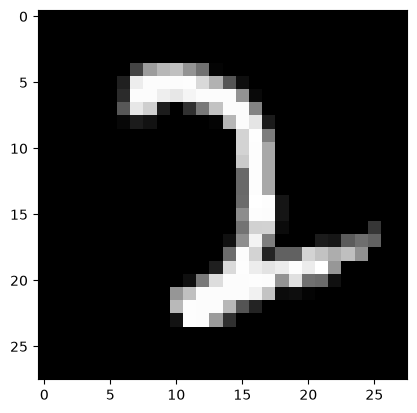

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [19]:
n = 13

# Pick one image from the test batch
single_img = data1[n].unsqueeze(0)

# Convert image to spike train
spike_img = spikegen.rate(single_img, num_steps=num_steps)

# Run through network
s, m = net(spike_img)

# Sum spikes across all timesteps
s_sum = s.sum(dim=0)

# Predicted class
pc = s_sum.argmax(dim=1)

print("original no ", targets1[n].item())
print("predicted no ", pc.item())

plt.imshow(data1[n].squeeze(), cmap='gray')
plt.show()

print(s)

In [21]:
num_epochs = 5
loss_hist = []
test_acc_hist = []
counter = 0
# Outer training loop
for epoch in range(num_epochs):
    for data, targets in iter(train_loader):
        spike_data = spikegen.rate(data, num_steps=num_steps)
        spk_rec, _ = net(spike_data)
        loss_val = loss(spk_rec, targets)
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
        loss_hist.append(loss_val.item())
        if counter % 50 == 0:
            with torch.no_grad():
                net.eval()
                test_acc = batch_accuracy(
                    test_loader,
                    net,
                    num_steps
                )
                print(
                    f"Iteration {counter}, Test Acc: {test_acc * 100:.2f}%\n"
                )

                test_acc_hist.append(test_acc.item())

                net.train()   # <- important

        counter += 1

Iteration 0, Test Acc: 43.38%

Iteration 50, Test Acc: 88.00%

Iteration 100, Test Acc: 90.36%

Iteration 150, Test Acc: 91.81%

Iteration 200, Test Acc: 91.92%

Iteration 250, Test Acc: 93.12%

Iteration 300, Test Acc: 93.47%

Iteration 350, Test Acc: 94.22%

Iteration 400, Test Acc: 94.26%

Iteration 450, Test Acc: 94.46%

Iteration 500, Test Acc: 94.91%

Iteration 550, Test Acc: 94.72%

Iteration 600, Test Acc: 95.32%

Iteration 650, Test Acc: 95.53%

Iteration 700, Test Acc: 95.55%

Iteration 750, Test Acc: 95.59%

Iteration 800, Test Acc: 95.91%

Iteration 850, Test Acc: 95.29%

Iteration 900, Test Acc: 96.13%

Iteration 950, Test Acc: 96.27%

Iteration 1000, Test Acc: 96.33%

Iteration 1050, Test Acc: 96.59%

Iteration 1100, Test Acc: 96.57%

Iteration 1150, Test Acc: 96.35%

Iteration 1200, Test Acc: 96.70%

Iteration 1250, Test Acc: 96.75%

Iteration 1300, Test Acc: 96.88%

Iteration 1350, Test Acc: 96.79%

Iteration 1400, Test Acc: 96.85%

Iteration 1450, Test Acc: 97.02%

Ite

original no  2
predicted no  2


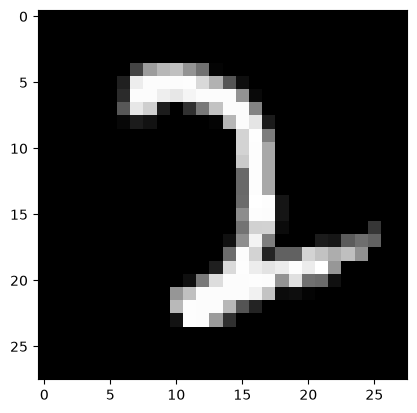

tensor([[[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 1., 0., 0., 0., 0., 0., 0., 

In [22]:
n = 13

# Pick one image from the test batch
single_img = data1[n].unsqueeze(0)

# Convert image to spike train
spike_img = spikegen.rate(single_img, num_steps=num_steps)

# Run through network
s, m = net(spike_img)

# Sum spikes across all timesteps
s_sum = s.sum(dim=0)

# Predicted class
pc = s_sum.argmax(dim=1)

print("original no ", targets1[n].item())
print("predicted no ", pc.item())

plt.imshow(data1[n].squeeze(), cmap='gray')
plt.show()

print(s)

In [23]:
wrong_imgs = []
wrong_preds = []
wrong_labels = []

net.eval()

with torch.no_grad():

    for data, targets in test_loader:

        # Convert batch to spike train
        spike_data = spikegen.rate(data, num_steps=num_steps)

        # Forward pass
        spk_rec, mem_rec = net(spike_data)

        # Sum spikes over time
        spk_sum = spk_rec.sum(dim=0)

        # Predicted class
        preds = spk_sum.argmax(dim=1)

        # Find wrong predictions
        wrong = preds != targets

        wrong_imgs.extend(data[wrong])
        wrong_preds.extend(preds[wrong])
        wrong_labels.extend(targets[wrong])

print("Total wrong predictions:", len(wrong_imgs))

Total wrong predictions: 270


Actual : 5
Predicted : 0


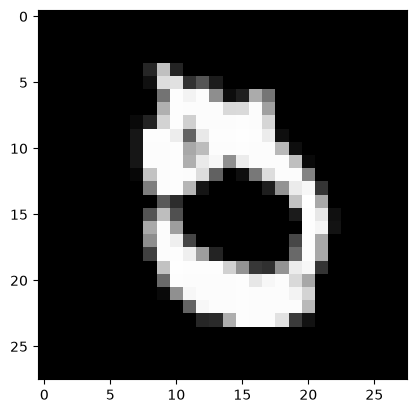

In [26]:
n = 23
plt.imshow(wrong_imgs[n].squeeze(), cmap='gray')

print("Actual :", wrong_labels[n].item())
print("Predicted :", wrong_preds[n].item())

plt.show()